**1.**
Questa cella installa le librerie necessarie per eseguire il codice. Usiamo transformers per il modello BERT, torch per le operazioni sui tensori, scikit-learn per la divisione del dataset e le metriche, nltk per il preprocessing del testo e tabulate per la visualizzazione tabellare (anche se non usato esplicitamente). Specificando transformers>=4.30.0 ci assicuriamo di avere una versione recente per evitare problemi con parametri deprecati come pad_to_max_length.

In [ ]:
# Installazione delle librerie necessarie
!pip install transformers>=4.30.0
!pip install torch
!pip install tabulate
!pip install scikit-learn
!pip install nltk

**2**.
Questa cella importa tutte le librerie e i moduli necessari per il progetto, incluse le funzioni per il preprocessing del testo, la gestione dei dati, l'addestramento del modello e la visualizzazione dei risultati. Verifica la versione di transformers per confermare che sia aggiornata e controlla la disponibilità della GPU, spostando il modello sul dispositivo appropriato (GPU o CPU). La stampa delle informazioni sul dispositivo aiuta a confermare che l'ambiente è configurato correttamente.

In [ ]:
import numpy as np
import pandas as pd
import time
import datetime
import random
import nltk
nltk.download('stopwords')
import re
from tabulate import tabulate
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import transformers
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Verifica della versione di transformers
print("Transformers version:", transformers.__version__)

# Verifica della disponibilità della GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using CPU.")
print("Device in use:", device)

Transformers version: 5.12.0
GPU available: Tesla T4
Device in use: cuda:0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**3**.
Questa cella carica il dataset movie_cleaned.csv, che contiene due colonne: text (recensioni di film) e label (etichette binarie 0 per negative, 1 per positive). Stampa le prime 10 righe per un controllo visivo e mostra la distribuzione delle etichette usando Counter per verificare il bilanciamento delle classi. Il codice include un'opzione commentata per caricare il file manualmente tramite l'interfaccia di Colab, utile se non è già presente in /content/.

In [ ]:

df = pd.read_csv("/content/movie_cleaned.csv", engine="python", on_bad_lines='warn')
print("Dataset loaded successfully.")

# Controllo valori mancanti o vuoti
print("Valori mancanti in 'text':", df['text'].isna().sum())
print("Frasi vuote in 'text':", df['text'].apply(lambda x: isinstance(x, str) and len(x.strip()) == 0).sum())
print(df.head(10))
print("Label distribution:", Counter(df['label']))

Dataset loaded successfully.
Valori mancanti in 'text': 0
Frasi vuote in 'text': 0
                                                text  label
0  I grew up (b. 1965) watching and loving the Th...      0
1  When I put this movie in my DVD player, and sa...      0
2  Why do people who do not know what a particula...      0
3  Even though I have great interest in Biblical ...      0
4  Im a die hard Dads Army fan and nothing will e...      1
5  A terrible movie as everyone has said. What ma...      0
6  Finally watched this shocking movie last night...      1
7  I caught this film on AZN on cable. It sounded...      0
8  It may be the remake of 1987 Autumn's Tale aft...      1
9  My Super Ex Girlfriend turned out to be a plea...      1
Label distribution: Counter({1: 19908, 0: 19815})


**4**.
Questa cella definisce una funzione clean_text per preprocessare il testo, rimuovendo URL, tag HTML, punteggiatura ed emoji, e convertendo il testo in minuscolo. La rimozione delle stopwords è commentata, poiché BERT è progettato per gestire testo grezzo e le stopwords possono contenere informazioni utili. La funzione gestisce anche valori non validi (es. non stringhe) restituendo una stringa vuota. Il preprocessing viene applicato alla colonna text del dataset, preparando i dati per la tokenizzazione.

In [ ]:
# Funzione per il preprocessing del testo ottimizzata per BERT
from nltk.corpus import stopwords
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""  # Gestisci valori non stringa
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # Rimuovi URL
    html = re.compile(r'<.*?>')
    text = html.sub(r'', text)  # Rimuovi HTML

    # NOTA: La rimozione manuale di punteggiatura ed emoji è stata eliminata
    # per preservare la struttura sintattica delle frasi sfruttata da BERT.
    return text

df['text'] = df['text'].apply(clean_text)
print("Text preprocessing completed.")

Text preprocessing completed.


**5**.
Questa cella mescola il dataset per randomizzare l'ordine delle righe, riducendo il rischio di bias legati all'ordine dei dati. Divide quindi il dataset in train (80%) e test (20%) usando train_test_split con l'opzione stratify per mantenere il bilanciamento delle classi. Estrae le sentences e le labels dal set di training per la successiva tokenizzazione. La stampa delle dimensioni e della distribuzione delle etichette aiuta a verificare la correttezza della divisione.

In [ ]:

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print('Train length:', len(train_df))
print(train_df.groupby(['label'])['text'].count())
print('Test length:', len(test_df))
print(test_df.groupby(['label'])['text'].count())

sentences = train_df['text'].tolist()
labels = train_df['label'].tolist()

Train length: 31778
label
0    15852
1    15926
Name: text, dtype: int64
Test length: 7945
label
0    3963
1    3982
Name: text, dtype: int64


**6**.
Questa cella carica il tokenizer di BERT (bert-base-uncased) e calcola la lunghezza massima e media delle frasi per determinare un valore appropriato per MAX_LEN.MAX_LEN=128 come default, un compromesso tra copertura delle frasi e efficienza computazionale. Tokenizza le frasi del train set usando encode_plus, assicurando padding e troncamento a MAX_LEN con padding='max_length' e truncation=True. Filtra frasi vuote o non valide e verifica che tutti i tensori abbiano la forma corretta (1, 128) prima della concatenazione, evitando il RuntimeError. Infine, concatena i tensori e stampa le loro dimensioni.

In [ ]:
# Caricamento del tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Imposta MAX_LEN a 256 (coerente con la descrizione e l'architettura scelta)
MAX_LEN = 256

# Filtra sentences vuote o non valide
valid_sentences = [sent for sent in sentences if isinstance(sent, str) and len(sent.strip()) > 0]
valid_labels = [labels[i] for i in range(len(sentences)) if isinstance(sentences[i], str) and len(sentences[i].strip()) > 0]

if len(valid_sentences) != len(sentences):
    print(f"Warning: {len(sentences) - len(valid_sentences)} empty or invalid sentences were removed.")

print("Tokenizzazione del train set massiva e parallela in corso...")
# Tokenizzazione immediata dell'intera lista (Parallelized in Rust)
encoded_inputs = tokenizer(
    text=valid_sentences,
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

input_ids = encoded_inputs['input_ids']
attention_masks = encoded_inputs['attention_mask']
labels_tensor = torch.tensor(valid_labels, dtype=torch.long)

print(f"Input IDs shape: {input_ids.shape}")
print(f"Attention Masks shape: {attention_masks.shape}")
print(f"Labels shape: {labels_tensor.shape}")

# Visualizzazione della tokenizzazione della prima riga (Copia singola pulita)
index = 0
print('\nOriginal:', valid_sentences[index])
tokens = tokenizer.tokenize(valid_sentences[index])
token_ids = tokenizer.convert_tokens_to_ids(tokens)
table = np.array([tokens[:20], token_ids[:20]]).T
print(tabulate(table, headers=['Tokens', 'Token IDs'], tablefmt='fancy_grid'))

# Visualizzazione dei token e dell'attention mask di una frase casuale
def print_rand_sentence_encoding():
    '''Displays tokens, token IDs and attention mask of a random text sample'''
    idx = random.randint(0, len(valid_sentences) - 1)
    tks = tokenizer.tokenize(valid_sentences[idx])
    t_ids = tokenizer.convert_tokens_to_ids(tks)
    att = [i.numpy() for i in attention_masks[idx]][:len(tks)]

    tbl = np.array([tks, t_ids, att]).T
    print("\nEsempio casuale dal dataset:", valid_sentences[idx])
    print(tabulate(tbl, headers=['Tokens', 'Token IDs', 'Attention Mask'], tablefmt='fancy_grid'))

print_rand_sentence_encoding()

Tokenizzazione del train set massiva e parallela in corso...
Input IDs shape: torch.Size([31778, 256])
Attention Masks shape: torch.Size([31778, 256])
Labels shape: torch.Size([31778])

Original: there are some elements that save this movie from being a total catastrophe, but are overshadowed with bad acting, plot holes, deus ex machina thrown ins, stupid dialogs, weak script, and predictable clichés...what we have here is a horror movie with a storyline that goes nowhere for most of the time. a group of unlikely heroes including a black guy that gets it first (yeah, that cliché seems to be still very much alive even in finland), seem to have trouble trying to exit a mysteriously empty hospital. there are shrieking ghosts (very imaginative), zombies (at one point i thought at least they didn't use zombies, but they came), and finnish glam-rock band with demonic make-up on, getting in their way. there is also some time-shift doodle present, but it adds up nothing to the storyline. autis

In [ ]:
# Visualizzazione della tokenizzazione della prima riga
index = 0
print('Original:', valid_sentences[index])
table = np.array([tokenizer.tokenize(valid_sentences[index]),
                  tokenizer.convert_tokens_to_ids(tokenizer.tokenize(valid_sentences[index]))]).T
print(tabulate(table, headers=['Tokens', 'Token IDs'], tablefmt='fancy_grid'))

Original: there are some elements that save this movie from being a total catastrophe, but are overshadowed with bad acting, plot holes, deus ex machina thrown ins, stupid dialogs, weak script, and predictable clichés...what we have here is a horror movie with a storyline that goes nowhere for most of the time. a group of unlikely heroes including a black guy that gets it first (yeah, that cliché seems to be still very much alive even in finland), seem to have trouble trying to exit a mysteriously empty hospital. there are shrieking ghosts (very imaginative), zombies (at one point i thought at least they didn't use zombies, but they came), and finnish glam-rock band with demonic make-up on, getting in their way. there is also some time-shift doodle present, but it adds up nothing to the storyline. autistic girl and a hobo seem to have some deeper understanding of a situation, but they never spell it out to the viewer, or their confused friends. their lines consist only of profound life

In [ ]:
# Visualizzazione dei token e dell'attention mask di una frase casuale
def print_rand_sentence_encoding():
    '''Displays tokens, token IDs and attention mask of a random text sample'''
    index = random.randint(0, len(valid_sentences) - 1)
    tokens = tokenizer.tokenize(valid_sentences[index])
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    attention = [i.numpy() for i in attention_masks[index]][:len(tokens)]  # Troncato per corrispondere ai token

    table = np.array([tokens, token_ids, attention]).T
    print(valid_sentences[index])
    print(tabulate(table,
                   headers=['Tokens', 'Token IDs', 'Attention Mask'],
                   tablefmt='fancy_grid'))

print_rand_sentence_encoding()

i've read plenty of jane austen in my time and approve of several cinema/tv adaptations but this one we just don't need.rating is a 2 as i wouldn't say it's awful just so boring you will feel like you've wasted 90 minutes of your life. dull script matched by even duller acting. i've heard billie piper is ok in dr who (not a fan so can't confirm) but in this she just sucks. there is absolutely no chemistry between the leads. this is austen, it's supposed to be a romance!please don't let this put you off austen or historical dramas. there are plenty of better programmes to view.
╒═════════════╤═════════════╤══════════════════╕
│ Tokens      │   Token IDs │   Attention Mask │
╞═════════════╪═════════════╪══════════════════╡
│ i           │        1045 │                1 │
├─────────────┼─────────────┼──────────────────┤
│ '           │        1005 │                1 │
├─────────────┼─────────────┼──────────────────┤
│ ve          │        2310 │                1 │
├─────────────┼─────────

**7**. Questa cella crea un TensorDataset combinando input_ids, attention_masks e labels del train set. Divide il dataset in training (80%) e validation (20%) usando random_split. Configura i DataLoader per il training (con RandomSampler per mescolare i dati) e la validazione (con SequentialSampler per un ordine fisso), usando un batch_size=16 per bilanciare efficienza e stabilità del training. La stampa delle dimensioni dei set aiuta a verificare la suddivisione.#

In [ ]:
# Crea il dataset usando labels_tensor
dataset = TensorDataset(input_ids, attention_masks, labels_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print('Training samples:', train_size)
print('Validation samples:', val_size)

# Batch size
batch_size = 16

# DataLoader per train e validation
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
validation_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)

Training samples: 25422
Validation samples: 6356


**8**.
Questa cella carica il modello BertForSequenceClassification con bert-base-uncased, configurato per classificazione binaria (num_labels=2). Disabilita l'output delle attenzioni e degli stati nascosti per ridurre il consumo di memoria. Sposta il modello sul dispositivo (GPU o CPU). Configura l'ottimizzatore AdamW con un learning rate di 2e-5 (valore consigliato per BERT) e uno scheduler lineare senza warmup per semplificare. Specifica 4 epoche per il training, un numero standard per il fine-tuning di BERT.

In [ ]:
# ✅ FIX #1: dropout passato come parametro di configurazione,
#    evita di reinizializzare i pesi del layer lineare
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.3,       # <-- FIX: dropout nel config, non sovrascrivendo il classifier
    output_attentions=False,
    output_hidden_states=False,
)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

epochs = 4

total_steps = len(train_dataloader) * epochs

# ✅ FIX #2: warmup al 10% dei passi, migliora stabilità nelle prime epoche
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,   # <-- FIX: era 0
    num_training_steps=total_steps
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**9**.
Questa cella definisce due funzioni di supporto: flat_accuracy per calcolare l'accuratezza delle predizioni confrontando i logits (dopo argmax) con le etichette vere, e format_time per convertire i tempi di esecuzione in un formato leggibile (ore:minuti:secondi). Queste funzioni sono utilizzate nel training e nella validazione per monitorare le prestazioni e i tempi.

In [ ]:
# Funzione per calcolare l'accuratezza
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Funzione per formattare il tempo
def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

**10**.
Questa cella implementa il ciclo di addestramento per il modello BERT. Imposta un seed per la riproducibilità, esegue il training per 4 epoche e calcola la loss media per il training e la validazione. Durante il training, applica il clipping dei gradienti per prevenire esplosioni dei gradienti e aggiorna i parametri con l'ottimizzatore e lo scheduler. Durante la validazione, calcola accuratezza e F1-score, salvando il modello con la migliore accuratezza di validazione (usando state_dict per compatibilità). Raccoglie statistiche per ogni epoca (loss, accuratezza, F1-score, tempi).

In [ ]:
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
training_stats = []
total_t0 = time.time()
best_eval_accuracy = 0
patience = 2
epochs_no_improve = 0

for epoch_i in range(epochs):
    print(f'\n======== Epoch {epoch_i + 1} / {epochs} ========')
    print('Training...')
    t0 = time.time()
    total_train_loss = 0
    model.train()
    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        model.zero_grad()
        output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = output.loss
        total_train_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)
    print(f"  Average training loss: {avg_train_loss:.2f}")
    print(f"  Training epoch took: {training_time}")

    print("\nRunning Validation...")
    t0 = time.time()
    model.eval()
    total_eval_accuracy = 0
    total_eval_loss = 0
    total_eval_f1 = 0
    for batch in validation_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        with torch.no_grad():
            output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = output.loss
        total_eval_loss += loss.item()
        logits = output.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        total_eval_accuracy += flat_accuracy(logits, label_ids)
        total_eval_f1 += f1_score(label_ids, np.argmax(logits, axis=1), average='binary')

    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    avg_val_f1 = total_eval_f1 / len(validation_dataloader)
    validation_time = format_time(time.time() - t0)
    print(f"  Accuracy: {avg_val_accuracy:.2f}")
    print(f"  F1-Score: {avg_val_f1:.2f}")
    print(f"  Validation Loss: {avg_val_loss:.2f}")
    print(f"  Validation took: {validation_time}")

    # ✅ FIX #3: training_stats.append spostato QUI, prima del break,
    #    così l'ultima epoca viene sempre registrata anche con early stopping
    training_stats.append({
        'epoch': epoch_i + 1,
        'Training Loss': avg_train_loss,
        'Valid. Loss': avg_val_loss,
        'Valid. Accur.': avg_val_accuracy,
        'Valid. F1': avg_val_f1,
        'Training Time': training_time,
        'Validation Time': validation_time
    })

    if avg_val_accuracy > best_eval_accuracy:
        torch.save(model.state_dict(), 'bert_model.pt')
        best_eval_accuracy = avg_val_accuracy
        epochs_no_improve = 0
        print("  Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch_i + 1} epochs")
            break

print("\nTraining complete!")
print(f"Total training took {format_time(time.time() - total_t0)} (h:mm:ss)")


======== Epoch 1 / 4 ========
Training...
  Average training loss: 0.35
  Training epoch took: 0:19:58

Running Validation...
  Accuracy: 0.91
  F1-Score: 0.90
  Validation Loss: 0.24
  Validation took: 0:01:37
  Best model saved!

======== Epoch 2 / 4 ========
Training...
  Average training loss: 0.22
  Training epoch took: 0:20:02

Running Validation...
  Accuracy: 0.90
  F1-Score: 0.90
  Validation Loss: 0.32
  Validation took: 0:01:36

======== Epoch 3 / 4 ========
Training...
  Average training loss: 0.18
  Training epoch took: 0:20:02

Running Validation...
  Accuracy: 0.92
  F1-Score: 0.92
  Validation Loss: 0.30
  Validation took: 0:01:35
  Best model saved!

======== Epoch 4 / 4 ========
Training...
  Average training loss: 0.15
  Training epoch took: 0:20:01

Running Validation...
  Accuracy: 0.92
  F1-Score: 0.92
  Validation Loss: 0.33
  Validation took: 0:01:37
  Best model saved!

Training complete!
Total training took 1:26:58 (h:mm:ss)


*12*.
Questa cella crea un DataFrame con le statistiche di training (loss, accuratezza, F1-score, tempi) e le visualizza in forma tabellare. Genera due grafici: uno per la loss di training e validazione, utile per diagnosticare overfitting/underfitting, e uno per l'accuratezza di validazione, per valutare la convergenza del modello. I grafici usano seaborn per uno stile chiaro e leggibile.

       Training Loss  Valid. Loss  Valid. Accur.  Valid. F1 Training Time  \
epoch                                                                       
1           0.352539     0.241990       0.909548   0.904103       0:19:58   
2           0.221441     0.315847       0.904837   0.901488       0:20:02   
3           0.178135     0.304567       0.920540   0.917615       0:20:02   
4           0.146513     0.331548       0.921639   0.917936       0:20:01   

      Validation Time  
epoch                  
1             0:01:37  
2             0:01:36  
3             0:01:35  
4             0:01:37  


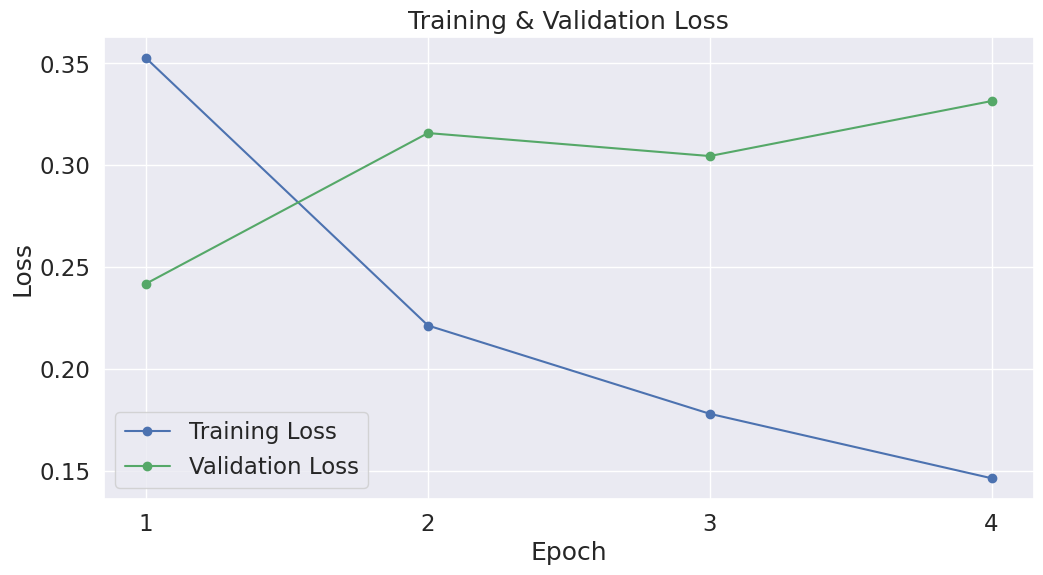

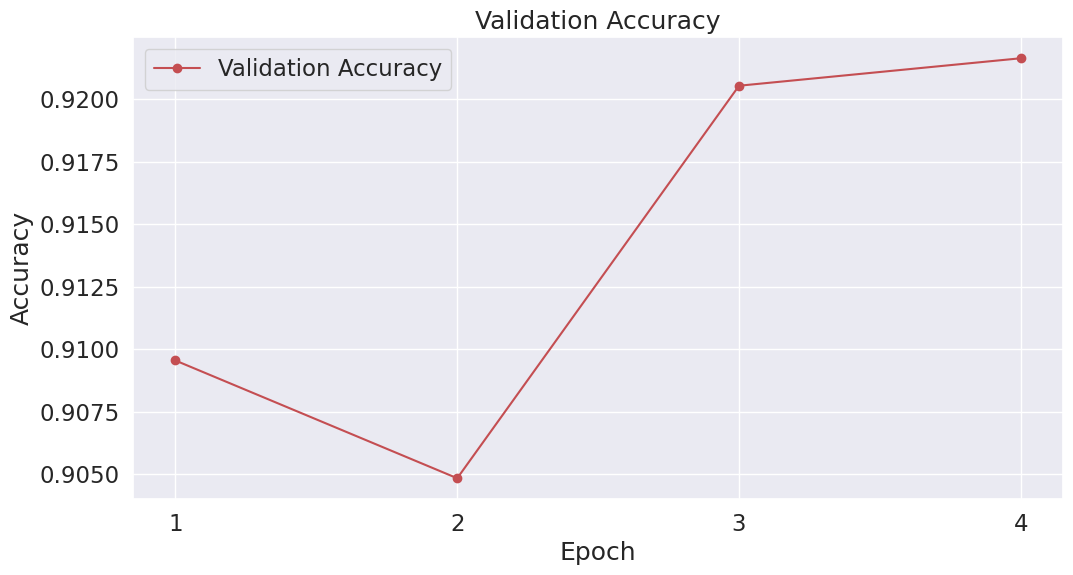

In [ ]:
# Visualizzazione delle statistiche di training
df_stats = pd.DataFrame(data=training_stats).set_index('epoch')
print(df_stats)

# Plot della learning curve
sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12, 6)
plt.plot(df_stats['Training Loss'], 'b-o', label="Training Loss")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks(range(1, len(df_stats) + 1))
plt.show()

# Plot dell'accuratezza
plt.plot(df_stats['Valid. Accur.'], 'r-o', label="Validation Accuracy")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(range(1, len(df_stats) + 1))
plt.show()

**13**.
Questa cella carica il modello migliore (salvato come bert_model.pt) e valuta le sue prestazioni sul test set. Tokenizza il test set con lo stesso processo usato per il train set, filtrando frasi vuote e verificando le shape dei tensori. Crea un DataLoader con batch_size=32 per l'inferenza e calcola le predizioni. Riporta l'accuratezza, l'F1-score e un report di classificazione dettagliato. Infine, visualizza una matrice di confusione normalizzata per analizzare gli errori di classificazione.

Tokenizzazione del test set massiva e parallela...
Predicting labels for test sentences...

Test Accuracy: 0.9251101321585903
Test F1-Score: 0.926859250153657

Classification Report:
               precision    recall  f1-score   support

    Negative       0.94      0.90      0.92      3963
    Positive       0.91      0.95      0.93      3982

    accuracy                           0.93      7945
   macro avg       0.93      0.93      0.93      7945
weighted avg       0.93      0.93      0.93      7945



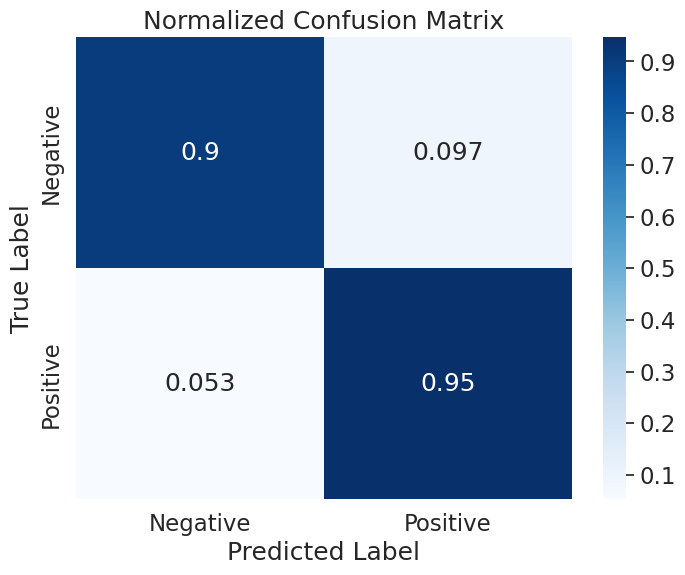


Esempi mal classificati (primi 5):
Testo: i am almost a two decade old human who's been reading comics most of my life. i'm not a huge fan of the fantastic four, but i'm fairly familiar with them. in 1994, roger corman (b-movie legend) produced the first, i think, feature length fantastic four film. the result was such pure schlock that it was never given a release. still, copies exist, mostly on the net and at conventions. if you're looking for a laugh and can find a copy do yourself a favor and check this thing out.the film basically retells the ff's origin and an encounter with doctor doom and a villain named the jeweler, essentially the mole man with a penchant for petty larceny. as is the case with these comic book movies, everything has to tie into everything, so the ff play a vital role in dr. doom's creation, and he and the jeweler play a vital role in theirs.first, i'd just like to mention that despite everything that went bad in this movie, i actually sort of liked the guy t

In [ ]:
# Caricamento del modello (con map_location per sicurezza CPU/GPU)
model.load_state_dict(torch.load('bert_model.pt', map_location=device))
model = model.to(device)
model.eval()

# Recupera testi e label del test set
sentences = test_df['text'].tolist()
raw_labels = test_df['label'].tolist()

valid_sentences = [sent for sent in sentences if isinstance(sent, str) and len(sent.strip()) > 0]
# ✅ CORREZIONE: usiamo raw_labels[i] associato al test set corrente
valid_labels = [raw_labels[i] for i in range(len(sentences)) if isinstance(sentences[i], str) and len(sentences[i].strip()) > 0]

if len(valid_sentences) != len(sentences):
    print(f"Warning: {len(sentences) - len(valid_sentences)} empty or invalid sentences were removed from test set.")

print('Tokenizzazione del test set massiva e parallela...')
encoded_test = tokenizer(
    text=valid_sentences,
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

input_ids = encoded_test['input_ids']
attention_masks = encoded_test['attention_mask']
labels_tensor = torch.tensor(valid_labels, dtype=torch.long)

batch_size = 32
prediction_data = TensorDataset(input_ids, attention_masks, labels_tensor)
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(prediction_data, sampler=prediction_sampler, batch_size=batch_size)

print('Predicting labels for test sentences...')
predictions, true_labels = [], []
for batch in prediction_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    predictions.append(logits)
    true_labels.append(label_ids)

# Combinazione robusta delle predizioni
scores = np.argmax(np.concatenate(predictions, axis=0), axis=1)
true_labels_flat = np.concatenate(true_labels, axis=0)

print("\nTest Accuracy:", accuracy_score(true_labels_flat, scores))
print("Test F1-Score:", f1_score(true_labels_flat, scores, average='binary'))
print("\nClassification Report:\n", classification_report(true_labels_flat, scores, target_names=['Negative', 'Positive']))

# Generazione Matrice di Confusione
cm = confusion_matrix(true_labels_flat, scores)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_df = pd.DataFrame(cm_normalized, index=['Negative', 'Positive'], columns=['Negative', 'Positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Stampa esempi mal classificati
incorrect_indices = [i for i in range(len(scores)) if scores[i] != true_labels_flat[i]]
print("\nEsempi mal classificati (primi 5):")
for idx in incorrect_indices[:5]:
    print(f"Testo: {valid_sentences[idx]}")
    print(f"Vero: {true_labels_flat[idx]}, Predetto: {scores[idx]}\n")ìì